# Análisis estadístico de ConnectaTel

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plans = pd.read_csv('plans.csv')
users = pd.read_csv('users_latam.csv')
usage = pd.read_csv('usage.csv')

In [12]:
plans.head(5)

,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [13]:
users.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


## Información sobre los DataFrames
- Analizamos cuántas filas y columnas tiene cada dataframe
- Analizamos la información básica de cada dataframe con el propósito de determinar qué debemos hacer en la limpieza y estandarización de los datos

In [14]:
print("plans", plans.shape)
print("users", users.shape)
print("usage", usage.shape)

plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [15]:
plans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


In [16]:
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [17]:
usage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


## Valores Ausentes

Encontramos los valores ausentes y su proporción. Lo realizaremos únicamente con los dataframes en los que se hallaron valores faltantes con la función .info()

In [18]:
print(users.isna().sum())
print(users.isna().mean())

user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64
user_id       0.00000
first_name    0.00000
last_name     0.00000
age           0.00000
city          0.11725
reg_date      0.00000
plan          0.00000
churn_date    0.88350
dtype: float64


In [19]:
print(usage.isna().sum())
print(usage.isna().mean())

id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64
id          0.00000
user_id     0.00000
type        0.00000
date        0.00125
duration    0.55190
length      0.44740
dtype: float64


## Detección de valores erróneos y sentinels

In [20]:
users["user_id"].describe()
users["age"].describe()

count    4000.000000
mean       33.739750
std       123.232257
min      -999.000000
25%        32.000000
50%        47.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

In [21]:
columnas_numericas_usage = ["duration", "length"]

for col in columnas_numericas_usage:
    print(usage[col].describe())
    print()


count    17924.000000
mean         5.202237
std          6.842701
min          0.000000
25%          1.437500
50%          3.500000
75%          6.990000
max        120.000000
Name: duration, dtype: float64

count    22104.000000
mean        52.127398
std         56.611183
min          0.000000
25%         37.000000
50%         50.000000
75%         64.000000
max       1490.000000
Name: length, dtype: float64



In [22]:
users["reg_date"] = pd.to_datetime(users["reg_date"])
print(users["reg_date"].dtype)

datetime64[ns]


In [23]:
usage['date'] = pd.to_datetime(usage["date"])
print(usage["date"].dtype)


datetime64[ns]


In [24]:
users['reg_date'].dt.year.value_counts()

reg_date
2024    1330
2023    1316
2022    1314
2026      40
Name: count, dtype: int64

In [25]:
age_mediana = users[users["age"] != -999]["age"].median()
users["age"] = users["age"].replace(-999, age_mediana)
users["age"].describe()

count    4000.000000
mean       48.136000
std        17.689919
min        18.000000
25%        33.000000
50%        48.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

In [26]:
# Reemplazar ? por NA en city
users["city"] = users["city"].replace('?', pd.NA)

# Verificar cambios
print(users["city"].describe())
print()
print(users["city"].value_counts())
print()
print('La cantidad de datos ausentes es:')
print(users["city"].isna().sum())

count       3435
unique         6
top       Bogotá
freq         808
Name: city, dtype: object

city
Bogotá      808
CDMX        730
Medellín    616
GDL         450
Cali        424
MTY         407
Name: count, dtype: int64

La cantidad de datos ausentes es:
565


In [27]:
# Marcar fechas futuras como NA para reg_date
users.loc[users['reg_date'].dt.year == 2026, 'reg_date'] = pd.NaT

# Verificar cambios
users['reg_date'].dt.year.value_counts(dropna = False)


reg_date
2024.0    1330
2023.0    1316
2022.0    1314
NaN         40
Name: count, dtype: int64

In [28]:
#Eliminamos los datos erróneos, en donde type == text & duration != NaN
usage.loc[(usage['type']=='text' )&(usage['duration'].notna()), 'duration'] = pd.NA
usage[(usage['type'] == 'text') & (usage['duration'].notna())]

,id,user_id,type,date,duration,length


In [29]:
usage['duration'].isna().groupby(usage['type']).mean().sort_values(ascending = False)

type
text    1.0
call    0.0
Name: duration, dtype: float64

In [30]:
usage['length'].isna().groupby(usage['type']).mean().sort_values(ascending = False)

type
call    0.99933
text    0.00000
Name: length, dtype: float64

In [31]:
usage[(usage['type'] == 'call') & (usage['length'].notna())]

,id,user_id,type,date,duration,length
2070,2071,13139,call,2024-01-10 08:48:27.432685817,1.68,1490.0
5272,5273,11750,call,2024-01-24 20:33:12.649816245,3.78,1490.0
10614,10615,13855,call,2024-02-18 00:42:33.183829595,0.53,1490.0
12692,12693,12263,call,2024-02-27 10:23:08.374709367,1.80,1490.0
16910,16911,12099,call,2024-03-17 12:28:18.882472061,3.29,1490.0
20727,20728,10599,call,2024-04-03 19:00:30.510762768,0.40,1490.0
20778,20779,11401,call,2024-04-04 00:32:49.969249231,1.01,1490.0
25444,25445,10781,call,2024-04-25 03:17:14.935873396,3.57,1490.0
26057,26058,11018,call,2024-04-27 21:51:39.407485186,0.63,1490.0
26506,26507,12400,call,2024-04-29 22:37:24.836120902,1.12,1490.0


## Agrupación por comportamiento de uso

In [32]:
# Columnas auxiliares
usage["is_text"] = (usage["type"] == "text").astype(int) #conocer el total de mensajes
usage["is_call"] = (usage["type"] == "call").astype(int) #conocer el total de llamadas


# Agrupar información por usuario
usage_agg = usage.groupby('user_id').agg({
    'is_text': 'sum',
    'is_call' : 'sum',
    'duration' : 'sum'
}).reset_index()

# observar resultado
usage_agg.head(3)

,user_id,is_text,is_call,duration
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [33]:
usage_agg = usage_agg.rename(columns={'is_text':'cant_mensajes','is_call':'cant_llamadas','duration':'cant_minutos_llamada'})
# observar resultado
usage_agg.head(3)

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [34]:
# Combinar la tabla agregada con el dataset de usuarios
user_profile = users.merge(usage_agg, on='user_id', how='left')
user_profile.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70
1,10001,Mateo,Torres,53,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01


In [35]:
# Resumen estadístico de las columnas numéricas
columnas_numericas = ['age','cant_mensajes','cant_llamadas','cant_minutos_llamada']
user_profile[columnas_numericas].describe()

,age,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,4000.000000,3999.000000,3999.000000,3999.000000
mean,48.136000,5.524381,4.478120,22.836934
std,17.689919,2.358416,2.144238,16.590213
min,18.000000,0.000000,0.000000,0.000000
25%,33.000000,4.000000,3.000000,11.095000
50%,48.000000,5.000000,4.000000,19.740000
75%,63.000000,7.000000,6.000000,31.185000
max,79.000000,17.000000,15.000000,155.690000


In [36]:
# Distribución porcentual del tipo de plan
user_profile['plan'].value_counts(normalize=True)

plan
Basico     0.64875
Premium    0.35125
Name: proportion, dtype: float64

## Histograma de edad
Utilizamos "hue" para agrupar los usuarios por el tipo de plan que manejan.

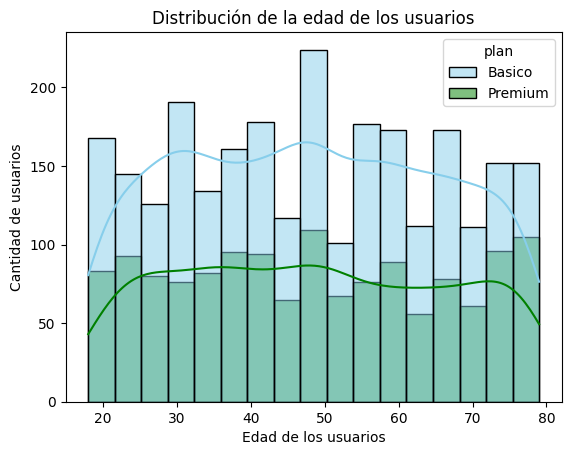

In [37]:
# Histograma para visualizar la edad (age)

sns.histplot(data = user_profile, x='age', hue='plan', palette=['skyblue','green'], kde=True)
plt.xlabel('Edad de los usuarios')
plt.ylabel('Cantidad de usuarios')
plt.title('Distribución de la edad de los usuarios')
plt.show()

💡Insights: 
- Distribución multimodal, en donde encontramos que la proporción de usuarios premium es mucho menor que los de plan básico. Encontramos en ambos grupos picos en diferentes edades, y coincidiendo en el rango de edad entre 45 y 50 años como el rango de pico más alto (más usuarios registrados), en el plan básico tenemos 261 usuarios y en el premium 132, por ende, se puede inferir que de cada 2 usuarios del plan básico se cuenta con 1 usuario del plan premium en el rango de edad con más usuarios registrados.

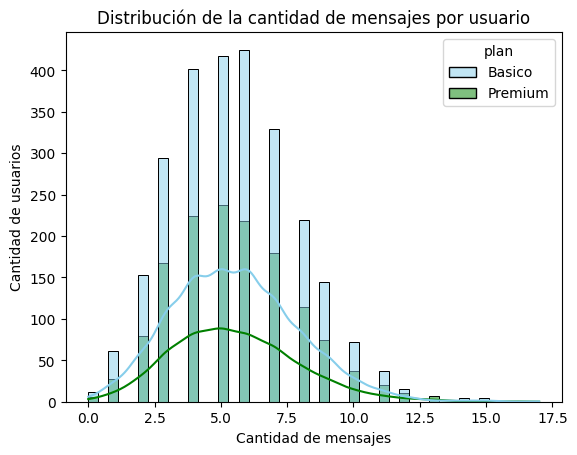

In [38]:
# Histograma para visualizar la cant_mensajes
sns.histplot(data = user_profile, x='cant_mensajes', hue='plan', palette=['skyblue','green'], kde=True)
plt.xlabel('Cantidad de mensajes')
plt.ylabel('Cantidad de usuarios')
plt.title('Distribución de la cantidad de mensajes por usuario')
plt.show()

💡Insights: 
- Distribución multimodal en donde los usuarios se concentran entre los picos generados en 2,5 hasta 7,5 mensajes por usuario. También, se nota un sesgo hacia la derecha, ya que los valores se concentran más hacia la izquierda (valores mínimos y medios), por el contrario, hacia la derecha (valores máximos) encontramos muy pocos registros de usuarios generando una cola (sesgo) hacia la derecha.


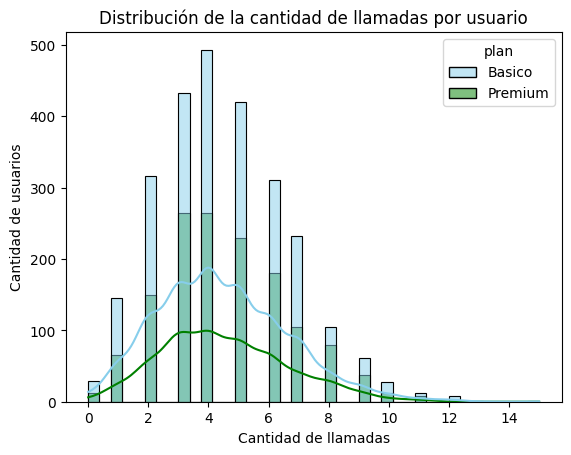

In [39]:
sns.histplot(data = user_profile, x='cant_llamadas', hue='plan', palette=['skyblue','green'], kde=True)
plt.xlabel('Cantidad de llamadas')
plt.ylabel('Cantidad de usuarios')
plt.title('Distribución de la cantidad de llamadas por usuario')
plt.show()

💡Insights: 
- Distribución multimodal también, en donde la concentración de los usuarios se encuentra en los valores medios/bajos, más específicamente, entre 2 y 8 llamadas por usuario, generando de esta manera, un pequeño sesgo hacia la derecha, ya que los usuarios con mayor cantidad de llamadas son muy pocos.

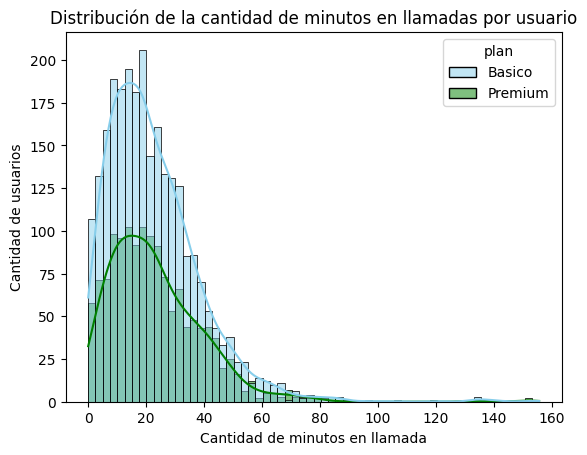

In [40]:
# Histograma para visualizar la cant_minutos_llamada
sns.histplot(data = user_profile, x='cant_minutos_llamada', hue='plan', palette=['skyblue','green'], kde=True)
plt.xlabel('Cantidad de minutos en llamada')
plt.ylabel('Cantidad de usuarios')
plt.title('Distribución de la cantidad de minutos en llamadas por usuario')
plt.show()

💡Insights: 
- Distribución con sesgo a la derecha, en donde encontramos la mayor concentración de los usuarios en los valores bajos, entre 0 y 30 minutos en llamadas, y encontramos datos muy alejados a la derecha, que llegan hasta 160 minutos.

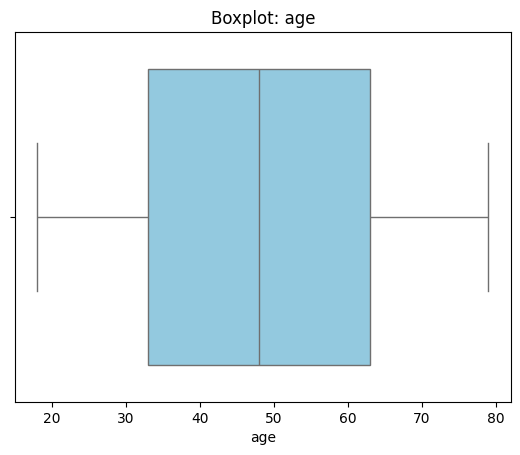

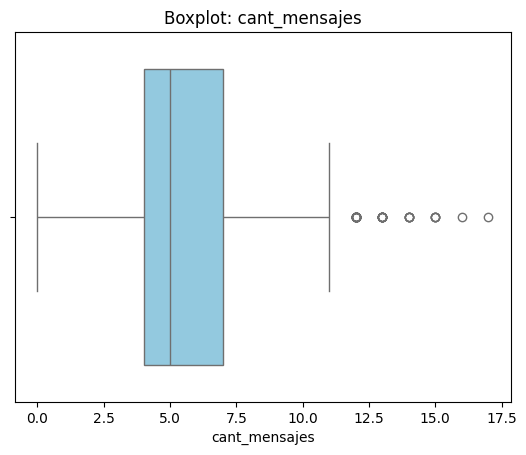

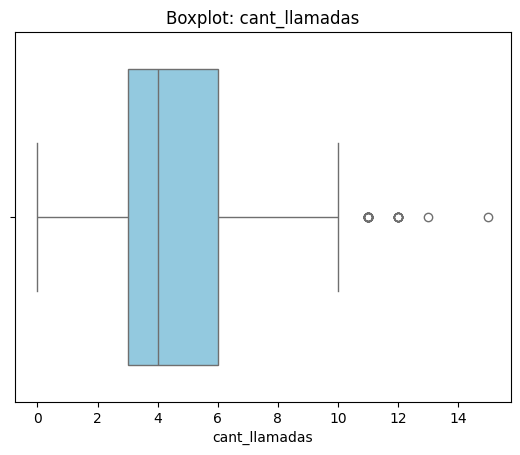

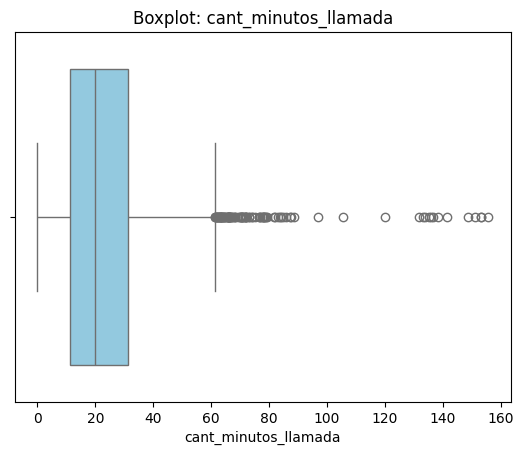

In [41]:
# Visualizando usando BoxPlot 
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_numericas:
    plt.figure()
    sns.boxplot(x = user_profile[col], color ='skyblue')
    plt.title(f'Boxplot: {col}')
    plt.show()

💡Insights: 
- Age: no presenta outliers. Los bigotes presentan tamaños similares. La caja (IQR) es ancha: la mayoría de los usuarios están concentrados en un rango de edad amplio, aproximadamente entre las edades de 30 y 60 años.
- cant_mensajes: sí presenta outliers: revelan usuarios con alta cantidad de mensajes enviados. Confirma el sesgo a la derecha que vimos en el histograma. La caja (IQR) es estrecha: la mayoría de los usuarios envían entre 4 y 7 mensajes.
- cant_llamadas: sí presenta outliers: revelan usuarios con alta cantidad de llamadas realizadas. Confirma el sesgo a la derecha que vimos en el histograma. La caja (IQR) es estrecha: la mayoría de los usuarios realizan entre 3 y 6 llamadas.
- cant_minutos_llamada: sí presenta outliers: revelan usuarios con alta cantidad de minutos en llamadas. Confirma el sesgo a la derecha que vimos en el histograma. La caja (IQR) es estrecha: la mayoría de los usuarios consumen entre 10 y 30 minutos en llamadas.

In [42]:
# Calcular límites con el método IQR

columnas_limites = ['cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_limites:
    print('Límites de la columna:', col)
    Q1 = user_profile[col].quantile(0.25)
    print('Quantile 1:', Q1)
    Q3 = user_profile[col].quantile(0.75)
    print('Quantile 3:', Q3)
    IQR = Q3 - Q1
    print('IQR:', IQR)
    Extremo_superior = Q3 + 1.5 * IQR
    print('El extremo superior es:', Extremo_superior)
    print()

Límites de la columna: cant_mensajes
Quantile 1: 4.0
Quantile 3: 7.0
IQR: 3.0
El extremo superior es: 11.5

Límites de la columna: cant_llamadas
Quantile 1: 3.0
Quantile 3: 6.0
IQR: 3.0
El extremo superior es: 10.5

Límites de la columna: cant_minutos_llamada
Quantile 1: 11.094999999999999
Quantile 3: 31.185
IQR: 20.09
El extremo superior es: 61.31999999999999



In [43]:
# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
user_profile[columnas_limites].describe()

,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,3999.000000,3999.000000,3999.000000
mean,5.524381,4.478120,22.836934
std,2.358416,2.144238,16.590213
min,0.000000,0.000000,0.000000
25%,4.000000,3.000000,11.095000
50%,5.000000,4.000000,19.740000
75%,7.000000,6.000000,31.185000
max,17.000000,15.000000,155.690000


💡Insights: 
- cant_mensajes: mantener o no outliers, porqué?: R// Se mantienen, debido a que se pueden entender como usuarios que están por encima de los valores típicos, no significan un error en los registros que implique eliminarlos y no tenerlos en cuenta.
- cant_llamadas: mantener o no outliers, porqué?: R// Se mantienen, debido a que se pueden entender como usuarios que están por encima de los valores típicos, no significan un error en los registros que implique eliminarlos y no tenerlos en cuenta.
- cant_minutos_llamada: mantener o no outliers, porqué?: R// Se mantienen, debido a que se pueden entender como 14 usuarios que tuvieron llamadas demasiado largas (~120min). 

## Segmentación de clientes por uso y por edad

In [44]:
# Crear columna grupo_uso
user_profile['grupo_uso'] = np.where(
    (user_profile['cant_llamadas']<5) & (user_profile['cant_mensajes']<5), "Bajo uso",
        np.where((user_profile['cant_llamadas']<10) & (user_profile['cant_mensajes']<10), "Uso medio", "Alto uso" 
    )
)

In [45]:
user_profile.head(3)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio
1,10001,Mateo,Torres,53,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio


In [46]:
user_profile.value_counts()

user_id  first_name  last_name  age  city      reg_date                       plan     churn_date   cant_mensajes  cant_llamadas  cant_minutos_llamada  grupo_uso
13994    Sofia       Torres     25   Medellín  2024-12-29 15:08:30.427606912  Basico   1,72109E+18  5.0            7.0            16.09                 Uso medio    1
10032    Carlos      Lopez      44   MTY       2022-01-09 18:17:33.263315829  Premium  1,71832E+18  8.0            2.0            19.12                 Uso medio    1
10038    Carlos      Torres     36   Medellín  2022-01-11 09:43:20.750187547  Premium  1,7261E+18   4.0            4.0            11.75                 Bajo uso     1
10042    Mateo       Gomez      56   Cali      2022-01-12 12:00:32.408102025  Basico   1,72169E+18  4.0            4.0            32.25                 Bajo uso     1
10044    Mateo       Garcia     58   Bogotá    2022-01-13 01:09:08.237059264  Basico   1,7312E+18   8.0            1.0            6.30                  Uso medio    1
   

In [47]:
# Crear columna grupo_edad
user_profile['grupo_edad'] = np.where(
    (user_profile['age']<30), "Joven",
        np.where((user_profile['age']<60), "Adulto", "Adulto Mayor" 
    )
)
user_profile.head(3)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso,grupo_edad
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio,Adulto
1,10001,Mateo,Torres,53,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso,Adulto
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio,Adulto


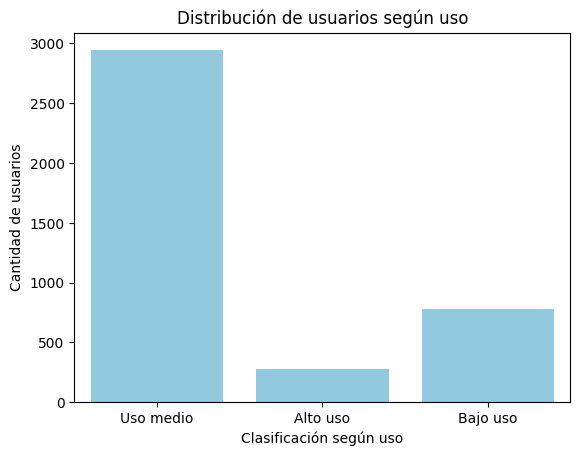

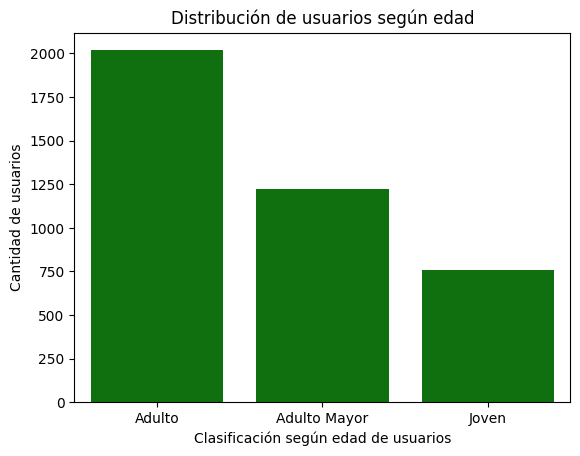

In [48]:
# Visualización de los segmentos por uso
sns.countplot(data=user_profile, x='grupo_uso', color='skyblue')
plt.xlabel('Clasificación según uso')
plt.ylabel('Cantidad de usuarios')
plt.title('Distribución de usuarios según uso')
plt.show()

# Visualización de los segmentos por edad
sns.countplot(data=user_profile, x='grupo_edad', color='green')
plt.xlabel('Clasificación según edad de usuarios')
plt.ylabel('Cantidad de usuarios')
plt.title('Distribución de usuarios según edad')
plt.show()

In [58]:
user_profile.groupby('plan')['grupo_uso'].value_counts()
print()
user_profile.groupby('plan')['grupo_uso'].value_counts(normalize=True)

plan     grupo_uso
Basico   Uso medio    0.731021
         Bajo uso     0.197303
         Alto uso     0.071676
Premium  Uso medio    0.744484
         Bajo uso     0.189324
         Alto uso     0.066192
Name: proportion, dtype: float64

In [61]:
user_profile.groupby('plan')['grupo_edad'].value_counts()
print()
user_profile.groupby('plan')['grupo_edad'].value_counts(normalize=True)

plan     grupo_edad  
Basico   Adulto          0.510597
         Adulto Mayor    0.302119
         Joven           0.187283
Premium  Adulto          0.493238
         Adulto Mayor    0.311744
         Joven           0.195018
Name: proportion, dtype: float64

### Análisis ejecutivo

⚠️ **Problemas detectados en los datos**
- Se encontraron 96 datos erróneos ('?') en la columna 'city', los cuales fueron reemplazados a valores nulos, por ende, esta columna quedó con un total de 565 valores ausentes (~14%).
- Se encontraron 55 datos erróneos en la columna 'age' (-999), los cuales fueron reemplazados con el valor de la mediana para que no crearan un sesgo erróneo.
- Se encontró una anomalía en la columna 'duration', en la cual, 16 registros que figuraban como tipo "text", contaban con una duración de 120 minutos, lo cual es un error ya que un mensaje de texto no puede tener duración, por ende, estos datos erróneos en los registros tipo mensaje de texto y que en la columna duración tenían el valor de 120, fueron modificados para que no crearan un sesgo erróneo en registros que luego de revisarlos cuidadosamente, se estaba seguro que no podían contener duración.
- Se encontraron 40 fechas de registro de usuarios correspondientes al 2026, esas fechas no fueron tenidas en cuenta debido a que las métricas que se tenían en el dataset 'usage' pertenecían al 2024, por ende, 2026 se consideró un año no transcurrido, por ende, fueron reemplazadas por valores nulos.

🚨 **Outliers**
- Los outliers de la cantidad de mensajes y cantidad de llamadas no están tan alejados del valor límite a la derecha, ya que no se encontraron outliers al lado izquierdo. Esos datos se consideraron extremos pero que pueden ser usuarios con un alto uso de su plan de datos. Ahora bien, en la duración si se encontraron datos muy alejados del valor límite, sin embargo, se consideró que pueden existir usuarios con un total de duración de llamadas superior a las dos horas. 


🔍 **Segmentos por Edad**
- Segmentamos los usuarios en 3 clasificaciones, joven (usuarios menores a 30 años), adulto(usuarios entre 30 y 60 años), y adulto mayor(usuarios mayores a 60 años).
- La mayor cantidad de usuarios se concentra en la clasificación 'adulto' con el 50,5% aproximadamente, seguido de la clasificación 'Adulto mayor' con 30,55% y por último los jóvenes con 19% del total.
- Comparando los datos entre el tipo de plan y la clasificación por edades, nos damos cuenta que la mayoría de adultos tienen registrado el plan básico con un 51% aproximadamente del total de los usuarios con plan básico, y así mismo, la clasificación adultos son los que mayor proporción tienen del total de usuarios con plan premium (~49,3%). Se puede decir que en ambos planes se tiene una distribución de los datos similar, los jovenes son los que menos proporción de usuarios tienen registrados con 18,7% en el plan básico y 19,5% en el plan premium. 


📊 **Segmentos por Nivel de Uso**
- Segmentamos los usuarios en clasificaciones según el uso de su plan, teniendo en cuenta la cantidad de llamadas y mensajes que han enviado. Se creó la clasificación 'Uso medio' que es la clasificación donde más usuarios se concentran, con aproximadamente el 73,6% del total, esta clasificación encasilla a los usuarios que envían entre 5 y 10 mensajes y/o llamadas, la siguiente clasificación con mayor cantidad de usuarios es la de 'Bajo uso' con aproximadamente el 19,45% del total de usuarios, que son los usarios que envían entre 0 y 5 mensajes y/o llamadas, y la menor cantidad de usuarios se encasillan en la clasificación 'Alto uso' con aproximadamente el 6,8%, estos usuarios envían más de 10 mensajes y/o llamadas.
- Los usuarios de la categoría 'Uso medio' en el plan básico son los que más proporción tienen, con 1.897 usuarios (~73,1% del total de usuarios que tienen registrado el plan básico), por el lado del plan premium, el 74,5% del total de usuarios registrados le dan un uso medio a su plan de telefonía. En ambos planes, la menor cantidad de usuarios son los que dan el mayor uso a su plan de datos.
  


➡️ Esto sugiere que los segmentos más valiosos para ConnectaTel son los usuarios adultos del plan básico, se podría intentar fidelizar aún más ese tipo de clientes y motivarlos a tener un plan premium, o crear algún otro tipo de plan que atraiga más usuarios adultos, o incluso jóvenes que puede ser un buen mercado potencial.


💡 **Recomendaciones**
- Se sugiere tener en cuenta los usuarios que tienen un alto uso de la duración de las llamadas. Analizar si puede existir la posibilidad de crear un plan que se adapte más a las necesidades de ellos, como en este caso la duración de llamadas, y así poder aumentar el nivel de ventas en el área comercial.
- Se propone realizar una campaña en el segmento de usuarios adultos registrados en el plan básico, al tener un uso generalmente medio de su plan de datos, se les puede ofrecer un plan más atractivo que enganche más y sea un intermedio entre el básico y el premium, e intentar hacer alianzas con plataformas para aumentar ventas ancladas a más servicios.